In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate synthetic data

In [3]:
time = np.linspace(0, 10, 50)
volatility = np.linspace(0.1, 2, 50)
T, V = np.meshgrid(time, volatility)


# True underlying function for price (nonlinear)

In [4]:

def true_price(t, v):
    return 10 + 2 * t + 5 * np.sin(v * t) + 0.5 * v**2 * t

P = true_price(T, V) + np.random.normal(0, 2, T.shape)  # Add noise

# 2. Prepare data for regression

In [6]:
X = np.column_stack([T.ravel(), V.ravel()])
y = P.ravel()


# 3. Polynomial regression (degree 3)

In [7]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
reg = LinearRegression()
reg.fit(X_poly, y)

LinearRegression()

# 4. Predict on a smooth grid for plotting

In [8]:
T_smooth = np.linspace(0, 10, 100)
V_smooth = np.linspace(0.1, 2, 100)
Tg, Vg = np.meshgrid(T_smooth, V_smooth)
Xg = np.column_stack([Tg.ravel(), Vg.ravel()])
Xg_poly = poly.transform(Xg)
Pg = reg.predict(Xg_poly).reshape(Tg.shape)

# 4. Predict on a smooth grid for plotting

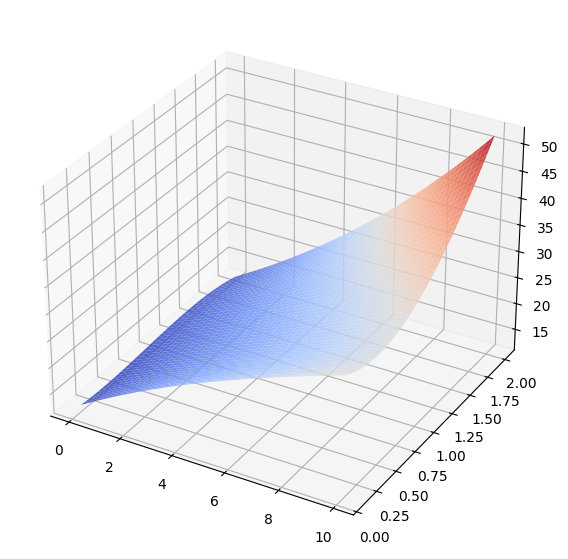

In [10]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Tg, Vg, Pg, cmap=cm.coolwarm, alpha=0.9, edgecolor='none')

In [11]:
contour = ax.contourf(Tg, Vg, Pg, zdir='z', offset=Pg.min()-10, cmap=cm.coolwarm, alpha=0.7)


In [12]:
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Volatility', fontsize=12)
ax.set_zlabel('Price', fontsize=12)
ax.set_title('Market Surface Predictor: Price vs Time vs Volatility', fontsize=14)

fig.colorbar(surf, shrink=0.5, aspect=10, label='Price')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>